#No code selection of GRID3 datasets -- friction surfaces, roads, and settlement blocks -- in Nigeria by LGA Administrative Names, Version 2

This Jupyter Notebook allows users to subset GRID3 data for Nigeria using LGA admisitrative names. This notebook can be used on Google Colab with no coding experience and no downloading of large datasets necessary.

### Recent Fixes included in Version 2:
1. Check size of geography, don't display if too large or RAM will run out. Current lowest size crash - 55,000km get size from bbox rather than geometry prov, ant, state for friction

2. Improved display and extract options

3. Removed library pop up/output

---


For more information please visit the [CIESIN Website](https://ciesin.columbia.edu/).

Or visit the [CIESIN Data User Guides](https://guides.ciesin.app/) site.

In [3]:
# @title Import libraries
# install arcgis API for accessing data
!pip install arcgis &> /dev/null
!pip install contextily &> /dev/null
#!pip install -U -q gdown

import contextily as cx

from arcgis.gis import GIS
from arcgis.features import FeatureLayer
from arcgis.geometry.filters import contains
import json
import arcgis
import matplotlib.pyplot as plt

import pandas as pd
import geopandas as gpd

import zipfile
import os
from pathlib import Path

In [4]:
# @title
from ipywidgets import Dropdown, VBox, Label, HBox, Layout, Checkbox
from IPython.display import display

# Anonymously authenticate arcgis API
gis = GIS()
# Read in service for NGA states
layer_url = "https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/NGA_State_Boundaries_V2/FeatureServer/0"
feature_layer = FeatureLayer(layer_url)

# Convert to feature set and subset by bounding box
feat = feature_layer.query()

# Convert to geojson
geoj_data = json.loads(feat.to_geojson)

# Convert to geodataframe
state = gpd.GeoDataFrame.from_features(geoj_data['features'], crs="epsg:4326")

unique_states = sorted(state['statename'].unique().tolist())

# Read in service for LGA
layer_url = "https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/NGA_LGA_Boundaries_2/FeatureServer/0"
feature_layer = FeatureLayer(layer_url)

# Convert to feature set and subset by bounding box
feat = feature_layer.query()

# Convert to geojson
geoj_data_lga = json.loads(feat.to_geojson)

# Convert to geodataframe
lga = gpd.GeoDataFrame.from_features(geoj_data_lga['features'], crs="epsg:4326")

# Read in service for Ward
layer_url = "https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/NGA_Ward_Boundaries/FeatureServer/0"
feature_layer = FeatureLayer(layer_url)

# Convert to feature set and subset by bounding box
feat = feature_layer.query()

# Initialize an empty list to store valid GeoJSON features
valid_geojson_features = []

# Iterate through each feature in the FeatureSet
for feature in feat.features:
    esri_geom_dict = None
    if feature.geometry is not None:
        if hasattr(feature.geometry, 'as_dict'):
            esri_geom_dict = feature.geometry.as_dict()
        elif isinstance(feature.geometry, dict):
            esri_geom_dict = feature.geometry

    geojson_geometry = None
    if esri_geom_dict:
        # Attempt a direct conversion by building a GeoJSON dict structure.
        if 'rings' in esri_geom_dict:
            geojson_geometry = {
                'type': 'Polygon',
                'coordinates': esri_geom_dict['rings']
            }
        elif 'paths' in esri_geom_dict:
            # GeoJSON 'MultiLineString' takes a list of LineString coordinate arrays
            geojson_geometry = {
                'type': 'MultiLineString',
                'coordinates': esri_geom_dict['paths']
            }
        elif 'x' in esri_geom_dict and 'y' in esri_geom_dict:
            geojson_geometry = {
                'type': 'Point',
                'coordinates': [esri_geom_dict['x'], esri_geom_dict['y']]
            }

    # Only append if we successfully obtained a valid GeoJSON geometry dictionary and properties
    if geojson_geometry and isinstance(geojson_geometry, dict) and geojson_geometry.get('type') is not None:
        geojson_feature = {
            "type": "Feature",
            "geometry": geojson_geometry,
            "properties": feature.attributes
        }
        valid_geojson_features.append(geojson_feature)

# Construct geoj_data_ward as a dictionary with 'type' and 'features'
geoj_data_ward = {
    "type": "FeatureCollection",
    "features": valid_geojson_features
}

# Convert to geodataframe
ward = gpd.GeoDataFrame.from_features(geoj_data_ward['features'], crs="epsg:4326")
ward

# Read in service for DRC health areas
layer_url = "https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/GRID3_COD_health_zones_v8_0/FeatureServer/0"
feature_layer = FeatureLayer(layer_url)

# Convert to feature set, excluding geometry
feat = feature_layer.query(return_geometry=False)

# Extract attributes directly into a list of dictionaries
health_zone_attributes = [f.attributes for f in feat.features]

# Convert the list of dictionaries to a pandas DataFrame
health_zones = pd.DataFrame(health_zone_attributes)

# set DRC variables as empty, they will be read in as geographies later if DRC is selected
province = None
antenne = None
zonesante = None

unique_provinces = sorted(health_zones['province'].unique().tolist())

# Create Label widgets for descriptions
country_label = Label("Country:")
geography_label = Label("Geography:")
friction_label = Label("Select Data to Extract:")
state_dyn_label = Label("State:")
lga_dyn_label = Label("LGA:")
ward_dyn_label = Label("Ward:")

# Create geography dropdown
geography_dropdown = Dropdown(
    options=(['State', 'LGA', 'Ward']),
    value='LGA',
    layout=Layout(width='auto')
)

ward_dropdown = Dropdown(options=[], layout=Layout(width='auto'))

# Create state dropdown
state_dropdown = Dropdown(options=unique_states, layout=Layout(width='auto'))

def get_lgas_in_state(state_name):
    lgas_in_state = lga[lga['statename'] == state_name]
    return sorted(lgas_in_state['lganame'].unique().tolist())

def get_wards_in_lga(state_name, lga_name):
    wards_in_lga = ward[(ward['statename'] == state_name) & (ward['lganame'] == lga_name)]
    return sorted(wards_in_lga['wardname'].unique().tolist())

def get_antennes_in_province(province_name):
    antennes_in_province = health_zones[health_zones['province'] == province_name]
    return sorted(antennes_in_province['antenne'].unique().tolist())

def get_zonesantes_in_antenne(province_name, antenne_name):
    zonesantes_in_antenne = health_zones[
        (health_zones['province'] == province_name) &
        (health_zones['antenne'] == antenne_name)
    ]
    return sorted(zonesantes_in_antenne['zonesante'].unique().tolist())

# Initialize global variables for country, state, and LGA
current_selected_country = 'Nigeria'
current_selected_geography = geography_dropdown.value # Initialized to 'LGA'
current_selected_state = state_dropdown.value
initial_lga_options = get_lgas_in_state(current_selected_state)
lga_dropdown = Dropdown(options=initial_lga_options, layout=Layout(width='auto'))
current_selected_lga = lga_dropdown.value
current_selected_ward = None # Initialized to None

# New global variables for DRC
current_selected_province = None
current_selected_antenne = None
current_selected_zonesante = None

# New variable for the name of the lowest selected geometry level value (e.g. 'Aketi')
lowest_selected_geometry_level_value = None
# New variable for the TYPE of the lowest selected geography (e.g. 'State', 'Zonesante')
geography_type = None

# Create country dropdown
country_dropdown = Dropdown(
    options=sorted(['Nigeria', 'Democratic Republic of the Congo']),
    value='Nigeria',
    layout=Layout(width='auto')
)

# Wrap label and dropdown for country
country_widget_group = VBox([country_label, country_dropdown])

# Wrap label and dropdown for geography
geography_widget_group = VBox([geography_label, geography_dropdown])

# Wrap label and dropdown for state/LGA/ward dynamically
state_widget_group = VBox([state_dyn_label, state_dropdown])
lga_widget_group = VBox([lga_dyn_label, lga_dropdown])
ward_widget_group = VBox([ward_dyn_label, ward_dropdown])

# Combined container for state/LGA/ward (nigeria_widgets_container will now be dynamic)
nigeria_widgets_container = VBox([state_widget_group, lga_widget_group, ward_widget_group])

# Create placeholder message for DRC
drc_message_label = Label("")
drc_message_container = VBox([drc_message_label], layout={'display': 'none'}) # Initially hidden

# Friction Surface options
friction_surface_options_nigeria = {
    "NGA Walking-based friction surface": "https://academiccommons.columbia.edu/doi/10.7916/97nc-wt39/download",
    "NGA Mixed friction surface": "https://academiccommons.columbia.edu/doi/10.7916/zvnx-2v35/download",
    "NGA All Roads": "https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/GRID3_NGA_roads/FeatureServer/0/",
    'NGA Major Roads':"https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/GRID3_NGA_roads/FeatureServer/0",
    'NGA Settlement Blocks':"https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/GRID3_NGA_settlement_extents_v4_0/FeatureServer/0/"
}
friction_surface_options_drc = {
    "DRC Walking-based friction surface": "https://academiccommons.columbia.edu/doi/10.7916/v1rc-7g38/download",
    "DRC Mixed friction surface": "https://academiccommons.columbia.edu/doi/10.7916/mw8y-3p73/download",
    "DRC All Roads": "https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/GRID3_COD_roads_v1_0/FeatureServer/0/",
    'DRC Major Roads':"https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/GRID3_COD_roads_v1_0/FeatureServer/0"
}

# Create friction dropdown (initially for Nigeria)
friction_dropdown = Dropdown(
    options=friction_surface_options_nigeria,
    value=friction_surface_options_nigeria["NGA Mixed friction surface"],
    layout=Layout(width='auto') # Keep width auto for the dropdown itself
)
selected_friction_type = friction_dropdown.value

def on_friction_dropdown_change(change):
    global selected_friction_type
    if change['type'] == 'change' and change['name'] == 'value':
        selected_friction_type = change['new']

friction_dropdown.observe(on_friction_dropdown_change)

# Wrap friction label and dropdown in a VBox
friction_widgets_container = VBox([friction_label, friction_dropdown])

# Create checkbox for downloading data locally
download_data_checkbox = Checkbox(
    value=False,
    description='Download data locally',
    disabled=False,
    indent=False
)

download_data_checkbox_value = download_data_checkbox.value

def on_download_data_checkbox_change(change):
    global download_data_checkbox_value
    if change['type'] == 'change' and change['name'] == 'value':
        download_data_checkbox_value = change['new']

download_data_checkbox.observe(on_download_data_checkbox_change)

# Wrap download data checkbox in a VBox
download_data_widgets_container = VBox([download_data_checkbox])

def handle_dropdown_change(change):
    global current_selected_state, current_selected_lga, current_selected_country, current_selected_ward, current_selected_province, current_selected_antenne, current_selected_zonesante, lowest_selected_geometry_level_value, geography_type
    if current_selected_country == 'Nigeria':
        if change['type'] == 'change' and change['name'] == 'value':
            current_selected_state = change['new']
            # Update LGA dropdown options based on the new state
            if current_selected_geography in ['LGA', 'Ward']:
                new_lga_options = get_lgas_in_state(current_selected_state)
                lga_dropdown.options = new_lga_options
                if new_lga_options:
                    lga_dropdown.value = new_lga_options[0]
                else:
                    lga_dropdown.value = None
                current_selected_lga = lga_dropdown.value

            # If geography is Ward, populate ward dropdown
            if current_selected_geography == 'Ward' and current_selected_lga:
                new_ward_options = get_wards_in_lga(current_selected_state, current_selected_lga)
                ward_dropdown.options = new_ward_options
                if new_ward_options:
                    ward_dropdown.value = new_ward_options[0]
                else:
                    ward_dropdown.value = None
                current_selected_ward = ward_dropdown.value
            # Update lowest_selected_geometry_level_value for Nigeria
            if current_selected_geography == 'State':
                lowest_selected_geometry_level_value = current_selected_state
            elif current_selected_geography == 'LGA':
                lowest_selected_geometry_level_value = current_selected_lga
            elif current_selected_geography == 'Ward':
                lowest_selected_geometry_level_value = current_selected_ward

    elif current_selected_country == 'Democratic Republic of the Congo':
        if change['type'] == 'change' and change['name'] == 'value':
            current_selected_province = change['new']

            if current_selected_geography in ['Antenne', 'Zonesante']:
                new_antenne_options = get_antennes_in_province(current_selected_province)
                lga_dropdown.options = new_antenne_options
                if new_antenne_options:
                    lga_dropdown.value = new_antenne_options[0]
                else:
                    lga_dropdown.value = None
                current_selected_antenne = lga_dropdown.value

            if current_selected_geography == 'Zonesante' and current_selected_antenne:
                new_zonesante_options = get_zonesantes_in_antenne(current_selected_province, current_selected_antenne)
                ward_dropdown.options = new_zonesante_options
                if new_zonesante_options:
                    ward_dropdown.value = new_zonesante_options[0]
                else:
                    ward_dropdown.value = None
                current_selected_zonesante = ward_dropdown.value
            # Update lowest_selected_geometry_level_value for DRC
            if current_selected_geography == 'Province':
                lowest_selected_geometry_level_value = current_selected_province
            elif current_selected_geography == 'Antenne':
                lowest_selected_geometry_level_value = current_selected_antenne
            elif current_selected_geography == 'Zonesante':
                lowest_selected_geometry_level_value = current_selected_zonesante
    else:
        current_selected_state = None
        current_selected_lga = None
        current_selected_ward = None
        current_selected_province = None
        current_selected_antenne = None
        current_selected_zonesante = None
        lowest_selected_geometry_level_value = None


def handle_lga_dropdown_change(change):
    global current_selected_lga, current_selected_country, current_selected_ward, current_selected_province, current_selected_antenne, current_selected_zonesante, lowest_selected_geometry_level_value, geography_type
    if current_selected_country == 'Nigeria':
        if change['type'] == 'change' and change['name'] == 'value':
            current_selected_lga = change['new']
            # Populate ward dropdown if geography is Ward
            if current_selected_geography == 'Ward' and current_selected_lga:
                new_ward_options = get_wards_in_lga(current_selected_state, current_selected_lga)
                ward_dropdown.options = new_ward_options
                if new_ward_options:
                    ward_dropdown.value = new_ward_options[0]
                else:
                    ward_dropdown.value = None
                current_selected_ward = ward_dropdown.value
            # Update lowest_selected_geometry_level_value for Nigeria
            if current_selected_geography == 'LGA':
                lowest_selected_geometry_level_value = current_selected_lga
            elif current_selected_geography == 'Ward':
                lowest_selected_geometry_level_value = current_selected_ward

    elif current_selected_country == 'Democratic Republic of the Congo':
        if change['type'] == 'change' and change['name'] == 'value':
            current_selected_antenne = change['new']
            if current_selected_geography == 'Zonesante' and current_selected_antenne:
                new_zonesante_options = get_zonesantes_in_antenne(current_selected_province, current_selected_antenne)
                ward_dropdown.options = new_zonesante_options
                if new_zonesante_options:
                    ward_dropdown.value = new_zonesante_options[0]
                else:
                    ward_dropdown.value = None
                current_selected_zonesante = ward_dropdown.value

            # Update lowest_selected_geometry_level_value for DRC
            if current_selected_geography == 'Antenne':
                lowest_selected_geometry_level_value = current_selected_antenne
            elif current_selected_geography == 'Zonesante':
                lowest_selected_geometry_level_value = current_selected_zonesante
    else:
        current_selected_lga = None
        current_selected_ward = None
        current_selected_antenne = None
        current_selected_zonesante = None
        lowest_selected_geometry_level_value = None

# Create new function on_geography_change
def on_geography_change(change):
    global current_selected_geography, current_selected_state, current_selected_lga, current_selected_ward, current_selected_province, current_selected_antenne, current_selected_zonesante, lowest_selected_geometry_level_value, geography_type
    current_selected_geography = change['new']
    geography_type = current_selected_geography # Update geography_type

    if current_selected_country == 'Nigeria':
        if current_selected_geography == 'State':
            state_widget_group.layout.display = 'block'
            lga_widget_group.layout.display = 'none'
            ward_widget_group.layout.display = 'none'
            current_selected_lga = None
            current_selected_ward = None
        elif current_selected_geography == 'LGA':
            state_widget_group.layout.display = 'block'
            lga_widget_group.layout.display = 'block'
            ward_widget_group.layout.display = 'none'
            current_selected_ward = None
        elif current_selected_geography == 'Ward':
            state_widget_group.layout.display = 'block'
            lga_widget_group.layout.display = 'block'
            ward_widget_group.layout.display = 'block'

        if current_selected_geography in ['LGA', 'Ward']:
            new_lga_options = get_lgas_in_state(current_selected_state)
            lga_dropdown.options = new_lga_options
            if new_lga_options:
                lga_dropdown.value = new_lga_options[0]
            else:
                lga_dropdown.value = None
            current_selected_lga = lga_dropdown.value

        if current_selected_geography == 'Ward' and current_selected_lga:
            new_ward_options = get_wards_in_lga(current_selected_state, current_selected_lga)
            ward_dropdown.options = new_ward_options
            if new_ward_options:
                ward_dropdown.value = new_ward_options[0]
            else:
                ward_dropdown.value = None
            current_selected_ward = ward_dropdown.value

        if current_selected_geography == 'State':
            lowest_selected_geometry_level_value = current_selected_state
        elif current_selected_geography == 'LGA':
            lowest_selected_geometry_level_value = current_selected_lga
        elif current_selected_geography == 'Ward':
            lowest_selected_geometry_level_value = current_selected_ward

    elif current_selected_country == 'Democratic Republic of the Congo':
        if current_selected_geography == 'Province':
            state_dropdown.options = unique_provinces
            if unique_provinces and unique_provinces[0]: # Check if unique_provinces is not empty and has elements
                state_dropdown.value = unique_provinces[0]
                current_selected_province = unique_provinces[0]
            else:
                state_dropdown.value = None
                current_selected_province = None

            state_widget_group.layout.display = 'block'
            lga_widget_group.layout.display = 'none'
            ward_widget_group.layout.display = 'none'
            current_selected_antenne = None
            current_selected_zonesante = None
            current_selected_lga = None
            current_selected_ward = None

        elif current_selected_geography == 'Antenne':
            state_dropdown.options = unique_provinces
            if unique_provinces and unique_provinces[0]: # Check if unique_provinces is not empty and has elements
                state_dropdown.value = unique_provinces[0]
                current_selected_province = unique_provinces[0]
            else:
                state_dropdown.value = None
                current_selected_province = None

            if current_selected_province:
                new_antenne_options = get_antennes_in_province(current_selected_province)
                lga_dropdown.options = new_antenne_options
                if new_antenne_options:
                    lga_dropdown.value = new_antenne_options[0]
                    current_selected_antenne = new_antenne_options[0]
                else:
                    lga_dropdown.value = None
                    current_selected_antenne = None

            else:
                lga_dropdown.options = []
                lga_dropdown.value = None
                current_selected_antenne = None


            state_widget_group.layout.display = 'block'
            lga_widget_group.layout.display = 'block'
            ward_widget_group.layout.display = 'none'
            current_selected_zonesante = None


        elif current_selected_geography == 'Zonesante':
            state_dropdown.options = unique_provinces
            if unique_provinces and unique_provinces[0]: # Check if unique_provinces is not empty and has elements
                state_dropdown.value = unique_provinces[0]
                current_selected_province = unique_provinces[0]
            else:
                state_dropdown.value = None
                current_selected_province = None
            current_selected_province = current_selected_province

            if current_selected_province:
                new_antenne_options = get_antennes_in_province(current_selected_province)
                lga_dropdown.options = new_antenne_options
                if new_antenne_options:
                    lga_dropdown.value = new_antenne_options[0]
                else:
                    lga_dropdown.value = None
                current_selected_antenne = None

            else:
                lga_dropdown.options = []
                lga_dropdown.value = None
                current_selected_antenne = None


            if current_selected_province and current_selected_antenne:
                new_zonesante_options = get_zonesantes_in_antenne(current_selected_province, current_selected_antenne)
                ward_dropdown.options = new_zonesante_options
                if new_zonesante_options:
                    ward_dropdown.value = new_zonesante_options[0]
                else:
                    ward_dropdown.value = None
                current_selected_zonesante = ward_dropdown.value

            else:
                ward_dropdown.options = []
                ward_dropdown.value = None
                current_selected_zonesante = None


            state_widget_group.layout.display = 'block'
            lga_widget_group.layout.display = 'block'
            ward_widget_group.layout.display = 'block'

        # Update lowest_selected_geometry_level_value for DRC
        if current_selected_geography == 'Province':
            lowest_selected_geometry_level_value = current_selected_province
        elif current_selected_geography == 'Antenne':
            lowest_selected_geometry_level_value = current_selected_antenne
        elif current_selected_geography == 'Zonesante':
            lowest_selected_geometry_level_value = current_selected_zonesante


def on_country_change(change):
    global current_selected_country, current_selected_state, current_selected_lga, current_selected_geography, current_selected_ward, current_selected_province, current_selected_antenne, current_selected_zonesante, lowest_selected_geometry_level_value, geography_type
    current_selected_country = change['new']

    if current_selected_country == 'Nigeria':

        geography_dropdown.options = (['State', 'LGA', 'Ward'])
        geography_dropdown.value = 'State'
        current_selected_geography = 'State'
        geography_type = current_selected_geography # Update geography_type

        # Set dynamic labels and visibility for Nigeria
        state_dyn_label.value = 'State:'
        lga_dyn_label.value = 'LGA:'
        ward_dyn_label.value = 'Ward:'

        nigeria_widgets_container.layout.display = 'block'
        drc_message_container.layout.display = 'none'

        state_dropdown.options = unique_states
        state_dropdown.value = unique_states[0]
        current_selected_state = state_dropdown.value

        # Update friction dropdown for Nigeria
        friction_dropdown.options = friction_surface_options_nigeria
        friction_dropdown.value = friction_surface_options_nigeria["NGA Mixed friction surface"]

        # Ensure initial display for state, LGA, and ward based on default 'State' geography
        state_widget_group.layout.display = 'block'
        lga_widget_group.layout.display = 'none'
        ward_widget_group.layout.display = 'none'

        current_selected_lga = None # Reset LGA when geography is State
        current_selected_ward = None # Reset Ward when geography is State
        current_selected_province = None
        current_selected_antenne = None
        current_selected_zonesante = None
        lowest_selected_geometry_level_value = current_selected_state # Initialize for Nigeria

    else: # Democratic Republic of the Congo

        geography_dropdown.options = (['Province', 'Antenne', 'Zonesante'])
        geography_dropdown.value = 'Province'
        current_selected_geography = 'Province'
        geography_type = current_selected_geography

        # Set dynamic labels and visibility for DRC
        state_dyn_label.value = 'Province:'
        lga_dyn_label.value = 'Antenne:'
        ward_dyn_label.value = 'Zonesante:'

        nigeria_widgets_container.layout.display = 'block'
        drc_message_container.layout.display = 'block'

        # Update friction dropdown for DRC
        friction_dropdown.options = friction_surface_options_drc
        friction_dropdown.value = friction_surface_options_drc["DRC Mixed friction surface"]

        # Initialize DRC-specific global variables
        current_selected_province = None
        current_selected_antenne = None
        current_selected_zonesante = None

        # Clear Nigeria-specific dropdowns (options and values updated by on_geography_change)
        state_dropdown.options = []
        lga_dropdown.options = []
        ward_dropdown.options = []

        current_selected_state = None
        current_selected_lga = None
        current_selected_ward = None
        lowest_selected_geometry_level_value = None # Reset for DRC initially, will be updated by on_geography_change

        # Trigger on_geography_change for DRC
        on_geography_change({'new': geography_dropdown.value, 'name': 'value', 'type': 'change'}) # This will set lowest_selected_geometry_level_value


state_dropdown.observe(handle_dropdown_change, names='value')
lga_dropdown.observe(handle_lga_dropdown_change, names='value')
country_dropdown.observe(on_country_change, names='value')
geography_dropdown.observe(on_geography_change, names='value')

# Set initial state based on the default country selection
on_country_change({'new': country_dropdown.value, 'name': 'value', 'type': 'change'})

# Display all main dropdowns horizontally
display(HBox([country_widget_group, geography_widget_group, nigeria_widgets_container, friction_widgets_container, download_data_widgets_container], layout=Layout(justify_content='space-around', align_items='center')))

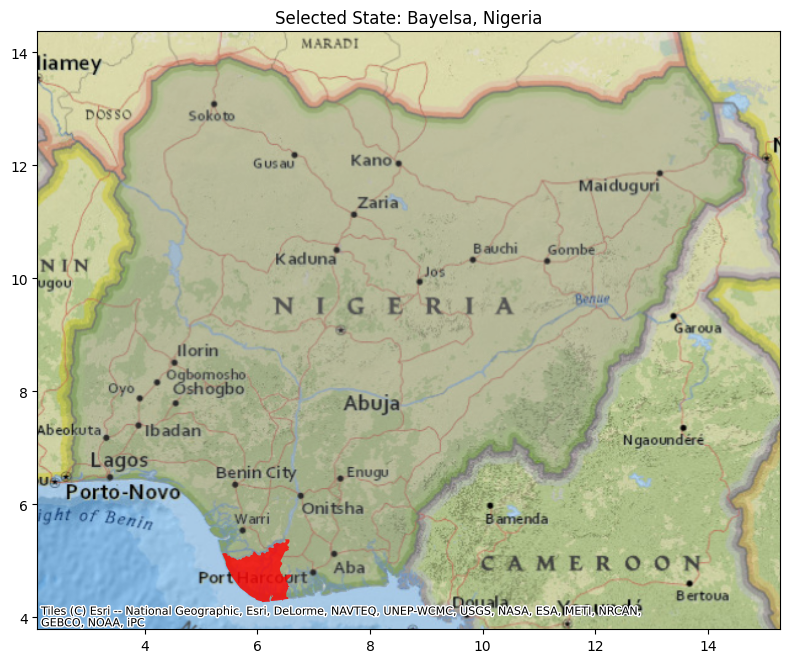

In [ ]:
# @title Display and set geometry - run everytime any dropdown selection is changed
# Get and display bounding geometry from selected geography

if current_selected_country == 'Nigeria':
  if current_selected_state is not None and current_selected_lga is None:
    name1 = current_selected_state + ", " + current_selected_country
    geog = state[state['statename'] == current_selected_state]

    # save country extent for plotting
    country_extent_geog = state

  elif current_selected_lga is not None and current_selected_ward is None:
    name1 = current_selected_lga + ", " + current_selected_state + ", " + current_selected_country
    geog = lga[lga['lganame'] == current_selected_lga]
    country_extent_geog = state

  else:
    name1 = current_selected_ward + ", " + current_selected_lga + ", " + current_selected_state + ", " + current_selected_country
    geog = ward[ward['wardname'] == current_selected_ward]
    country_extent_geog = state

elif current_selected_country == 'Democratic Republic of the Congo':
  # if drc is selected, geographic data still has to be read in (previously read in as non-geospatial data to save time)
  # check if drc geographic data has already been read in through this chunk
  if zonesante is not None:
    pass

  else:
    # Read in service for DRC
    layer_url = "https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/GRID3_COD_health_zones_v8_0/FeatureServer/0"
    feature_layer_drc = FeatureLayer(layer_url)

    # Convert to feature set and subset by bounding box
    feat = feature_layer_drc.query()

    # Convert to geojson
    geoj_data = json.loads(feat.to_geojson)

    # Convert to geodataframe
    zonesante = gpd.GeoDataFrame.from_features(geoj_data['features'], crs="epsg:4326")

    # Dissolve zonesante into antenne and province
    antenne = zonesante.dissolve(by='antenne')
    province = zonesante.dissolve(by='province')
    province.reset_index(inplace=True)
    antenne.reset_index(inplace=True)

  if current_selected_province is not None and current_selected_antenne is None:
    name1 = current_selected_province + ", " + current_selected_country
    geog = province[province['province'] == current_selected_province]
    country_extent_geog = province

  elif current_selected_antenne is not None and current_selected_zonesante is None:
    name1 = current_selected_antenne + ", " + current_selected_province + ", " + current_selected_country
    geog = antenne[antenne['antenne'] == current_selected_antenne]
    country_extent_geog = province

  else:
    name1 = current_selected_zonesante + ", " + current_selected_antenne + ", " + current_selected_province + ", " + current_selected_country
    geog = zonesante[zonesante['zonesante'] == current_selected_zonesante]
    country_extent_geog = province

# Plot data
fig, ax = plt.subplots(figsize=(8, 7))

# set title
ax.set_title(f"Selected {geography_type}: {name1}")

# plot country extent
country_extent_geog.plot(ax=ax, alpha=0.3, color='gray')

# plot geography extent
geog.plot(ax=ax, alpha=0.8, color='r')

# add basemap
cx.add_basemap(ax, source=cx.providers.Esri.NatGeoWorldMap, crs='EPSG:4326')

plt.tight_layout()
plt.show()

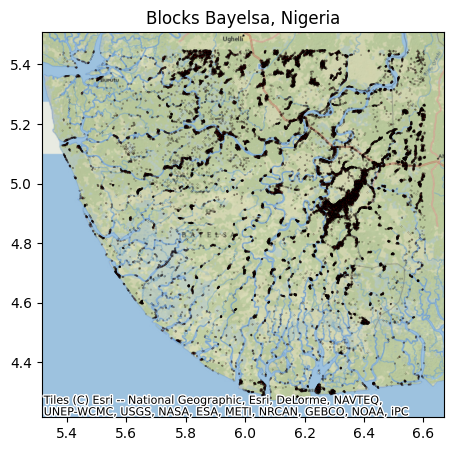

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# @title Clip, Display, and Download Data

# Extract data if not already extracted
# --------Friction Surface Extraction----------
# Download raster function
def dwn(url,filename):
  # Download the zip file
  !wget {url} -O {filename}

# extraction function
def extr(zip_name):
  # Specify the directory to extract the files
  extraction_path = '/content/extracted_data'
  os.makedirs(extraction_path, exist_ok=True)

  # Extract the zip file
  with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
      zip_ref.extractall(extraction_path)

# Get correct file name for walking and mixed
ls = ['https://academiccommons.columbia.edu/doi/10.7916/mw8y-3p73/download','https://academiccommons.columbia.edu/doi/10.7916/v1rc-7g38/download','https://academiccommons.columbia.edu/doi/10.7916/97nc-wt39/download','https://academiccommons.columbia.edu/doi/10.7916/zvnx-2v35/download']
if selected_friction_type in ls:
  # NGA
  # mixed
  if selected_friction_type == "https://academiccommons.columbia.edu/doi/10.7916/zvnx-2v35/download":
    zip_file_name = 'GRID3_NGA_mix_travel_time_friction_surface_v1_0.zip'
    path = '/content/extracted_data/GRID3_NGA_mix_travel_time_friction_surface_v1_0/GRID3_NGA_mix_travel_time_friction_surface_v1_0.tif'
    # check if file already exists
    if not os.path.exists(path):
      # download
      dwn(selected_friction_type, zip_file_name)
      # unzip
      extr(zip_file_name)

  # walk
  if selected_friction_type == "https://academiccommons.columbia.edu/doi/10.7916/97nc-wt39/download":
    zip_file_name = 'GRID3_NGA_walk_travel_time_friction_surface_v1_0.zip'
    path = "/content/extracted_data/GRID3_NGA_walk_travel_time_friction_surface_v1_0.tif/GRID3_NGA_walk_travel_time_friction_surface_v1_0.tif"
    if not os.path.exists(path):
      dwn(selected_friction_type, zip_file_name)
      extr(zip_file_name)


  # DRC
  # mix
  if selected_friction_type == "https://academiccommons.columbia.edu/doi/10.7916/mw8y-3p73/download":
    zip_file_name = 'GRID3_COD_mix_travel_time_friction_surface_v1.zip'
    path = "/content/extracted_data/GRID3_COD_mix_travel_time_friction_surface_v1.tif"
    if not os.path.exists(path):
      dwn(selected_friction_type, zip_file_name)
      extr(zip_file_name)

  # walk
  if selected_friction_type == "https://academiccommons.columbia.edu/doi/10.7916/v1rc-7g38/download":
    zip_file_name = 'GRID3_COD_walk_travel_time_friction_surface_v1.zip'
    path = "/content/extracted_data/GRID3_COD_walk_travel_time_friction_surface_v1.tif"
    if not os.path.exists(path):
      dwn(selected_friction_type, zip_file_name)
      extr(zip_file_name)

# --------Road Extraction----------
# Extract data if roads are selected
ls1 = ['https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/GRID3_COD_roads_v1_0/FeatureServer/0/','https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/GRID3_NGA_roads/FeatureServer/0/', 'https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/GRID3_COD_roads_v1_0/FeatureServer/0','https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/GRID3_NGA_roads/FeatureServer/0']
if selected_friction_type in ls1:
  layer_url = selected_friction_type
  feature_layer = FeatureLayer(layer_url)


# --------Block Extraction----------
# Extract data if roads are selected
ls3 = ['https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/GRID3_NGA_settlement_extents_v4_0/FeatureServer/0/']
if selected_friction_type in ls3:
  layer_url = selected_friction_type
  feature_layer = FeatureLayer(layer_url)




#----------------------------------#
# Clip and display

# Get cleaned filename
name2 = name1.replace(",", "_").replace(" ", "_").replace("-", "_").replace("__Democratic_Republic_of_the_Congo", "_DRC").replace("__", "_").replace("/", "_")

bbox = geog.total_bounds
from pyproj import Transformer

# Define input and output CRS
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32632", always_xy=True)

# Transform
bbox = transformer.transform_bounds(*bbox)

# Reshape bbox to be square
minx, miny, maxx, maxy = bbox
width = maxx - minx
height = maxy - miny

if width > height:
    diff = width - height
    miny -= diff / 2
    maxy += diff / 2
elif height > width:
    diff = height - width
    minx -= diff / 2
    maxx += diff / 2

bbox = (minx, miny, maxx, maxy)

import rasterio
from rasterio.windows import from_bounds
from rasterio.plot import show

def read_window_with_bounds(input_raster_path, bounds, t):
    minx, miny, maxx, maxy = bounds
    with rasterio.open(input_raster_path) as src:
        # Get the window corresponding to the bounds in the raster's CRS
        window = from_bounds(minx, miny, maxx, maxy, src.transform)

        # Read the data from that specific window
        clipped_data = src.read(1,window=window)

        transform=src.transform
        crs=src.crs
        profile = src.meta

        return clipped_data, crs, transform, profile, t

def get_roads(fl):
  import json
  # transform CRS
  transformer = Transformer.from_crs('32632', '3857', always_xy=True)
  xmin, ymin = transformer.transform(bbox[0], bbox[1])
  xmax, ymax = transformer.transform(bbox[2], bbox[3])

  # Create bounding box
  query_extent = {"xmin": xmin, "ymin": ymin, "xmax": xmax, "ymax": ymax, "spatialReference": {"wkid": 3857},}

  # Write spatial query
  query_filter = contains(query_extent, sr=3857)

  # Convert to feature set and subset by bounding box
  feat = fl.query(geometry_filter=query_filter)

  # Convert to geojson
  geojson_data = json.loads(feat.to_geojson)

  # Convert to geodataframe
  gdf = gpd.GeoDataFrame.from_features(geojson_data['features'], crs="3857")

  gdf = gdf.to_crs('4326')

  return(gdf)


def get_blocks(fl):
  import json
  # transform CRS
  transformer = Transformer.from_crs('32632', '3857', always_xy=True)
  xmin, ymin = transformer.transform(bbox[0], bbox[1])
  xmax, ymax = transformer.transform(bbox[2], bbox[3])

  # Create bounding box
  query_extent = {"xmin": xmin, "ymin": ymin, "xmax": xmax, "ymax": ymax, "spatialReference": {"wkid": 3857},}

  # Write spatial query
  query_filter = contains(query_extent, sr=3857)

  # Convert to feature set and subset by bounding box
  feat = fl.query(geometry_filter=query_filter)

  # Convert to geojson
  geojson_data = json.loads(feat.to_geojson)

  # Convert to geodataframe
  gdf = gpd.GeoDataFrame.from_features(geojson_data['features'], crs="4326")

  gdf = gdf.to_crs('4326')

  return(gdf)

try:
  if selected_friction_type == "https://academiccommons.columbia.edu/doi/10.7916/zvnx-2v35/download":
    clipped_data, crs, transform, profile, t = read_window_with_bounds("/content/extracted_data/GRID3_NGA_mix_travel_time_friction_surface_v1_0/GRID3_NGA_mix_travel_time_friction_surface_v1_0.tif", bbox, 1)
except:
  print('Mixed friction surface has not been extracted for NGA, rerun previous code block')

try:
  if selected_friction_type == "https://academiccommons.columbia.edu/doi/10.7916/97nc-wt39/download":
    clipped_data, crs, transform, profile, t = read_window_with_bounds("/content/extracted_data/GRID3_NGA_walk_travel_time_friction_surface_v1_0.tif/GRID3_NGA_walk_travel_time_friction_surface_v1_0.tif", bbox, 2)
except:
  print('Walking friction surface has not been extracted for NGA, rerun previous code block')

try:
  if selected_friction_type == "https://academiccommons.columbia.edu/doi/10.7916/mw8y-3p73/download":
    clipped_data, crs, transform, profile, t = read_window_with_bounds("/content/extracted_data/GRID3_COD_mix_travel_time_friction_surface_v1.tif", bbox, 1)
except:
  print('Mixed friction surface has not been extracted for DRC, rerun previous code block')

try:
  if selected_friction_type == "https://academiccommons.columbia.edu/doi/10.7916/v1rc-7g38/download":
    clipped_data, crs, transform, profile, t = read_window_with_bounds("/content/extracted_data/GRID3_COD_walk_travel_time_friction_surface_v1.tif", bbox, 2)
except:
  print('Walking friction surface has not been extracted for DRC, rerun previous code block')

# If friction surface is selected
if selected_friction_type in ls:
  # Write the clipped_data NumPy array to a new GeoTIFF file
  import rasterio.transform

  # Output numpy array to raster with original CRS
  # Define the output path for the GeoTIFF
  if t == 1:
    name = "mix_friction_surface_"+ name2
    output_geotiff_path = '/content/'+name+'.tif'
  if t == 2:
    name = "walk_friction_surface_"+ name2
    output_geotiff_path = '/content/'+name+'.tif'

  # Update the profile dictionary with the correct dimensions and transform for clipped_data
  updated_profile = profile.copy()
  updated_profile['height'] = clipped_data.shape[0]
  updated_profile['width'] = clipped_data.shape[1]

  # Recalculate the transform for the clipped data
  updated_profile['transform'] = rasterio.transform.from_origin(bbox[0], bbox[3], abs(transform.a), abs(transform.e))
  updated_profile['count'] = 1

  try:
      with rasterio.open(output_geotiff_path, 'w', **updated_profile) as dst:
          dst.write(clipped_data, 1)
      print(f"Clipped friction surface successfully written to: {output_geotiff_path}")
  except Exception as e:
      print(f"Error writing GeoTIFF: {e}")
  if geography_type in ("State", "Province", 'Antenne'):
    print('Geography too large to display - please download data to visualize')
  else:
  # Read in clipped raster and plot
    with rasterio.open(output_geotiff_path) as src:
            if t == 1:
              title = "Mixed Travel Friction Surface for" + " " + name1

            if t == 2:
              title = "Walking Travel Friction Surface for" + " " + name1
            fig, ax = plt.subplots(figsize=(10, 5))

            image = show(src, transform=transform, cmap='viridis', ax=ax, percent_range=(10, 70))

            fig.colorbar(ax.get_images()[0], ax=ax, label='Values')
            plt.title(title)
            plt.show()

# If road is selected
if selected_friction_type in ls1:
  if geography_type in ("no"):
    print('Geography too large to display - please download data to visualize')

  else:
    roads = get_roads(feature_layer)

    ls2 = ['https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/GRID3_NGA_roads/FeatureServer/0','https://services3.arcgis.com/BU6Aadhn6tbBEdyk/arcgis/rest/services/GRID3_COD_roads_v1_0/FeatureServer/0']
    if selected_friction_type in ls2:
      # get major roads
      vals = ['primary','secondary','trunk','tertiary']
      roads = roads[roads['class'].isin(vals)]
      title = 'Major Roads' + " " + name1
    else:
      title = 'Roads' + " " + name1

    # Plot roads
    ax = roads.plot(figsize=(10, 5), alpha=0.5, color='r')

    cx.add_basemap(ax, source=cx.providers.Esri.NatGeoWorldMap, crs='EPSG:4326')

    plt.title(title)
    plt.show()

# If blocks are selected
if selected_friction_type in ls3:
  if geography_type in ("no"):
    print('Geography too large to display - please download data to visualize')

  else:
    roads = get_blocks(feature_layer)

    title = 'Settlement Blocks' + " " + name1

    # Plot roads
    ax = roads.plot(figsize=(10, 5), alpha=0.5, color='r',edgecolor='black')

    cx.add_basemap(ax, source=cx.providers.Esri.NatGeoWorldMap, crs='EPSG:4326')

    plt.title(title)
    plt.show()

# Download data if option selected
if download_data_checkbox_value == True:
  from google.colab import files

  # Download Friction Surface
  if selected_friction_type in ls:
    files.download(output_geotiff_path)

  # Download major roads
  elif selected_friction_type in ls2:
    fp = "major_roads_" + name2
    roads.to_file(f"{fp}.gpkg", driver="GPKG")
    files.download(f"{fp}.gpkg")

  # Download roads
  elif selected_friction_type in ls1:
    fp = "roads_" + name2
    roads.to_file(f"{fp}.gpkg", driver="GPKG")
    files.download(f"{fp}.gpkg")

  # Download blocks
  elif selected_friction_type in ls3:
    fp = "settlement_blocks_" + name2
    roads.to_file(f"{fp}.gpkg", driver="GPKG")
    files.download(f"{fp}.gpkg")



